# 05 — Model Training & Evaluation
**FlightIQ — AI Travel Price Intelligence**

---
Trains Linear Regression, Random Forest, and Gradient Boosting on the cleaned dataset.
Evaluates all three on a held-out test set. Selects the best model and saves the full pipeline.


In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib, json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sys.path.insert(0, os.path.abspath('../src'))
from feature_engineering import prepare_data, load_data, ALL_FEATURES, get_feature_names
from model_training import run_training, evaluate, get_models, MODEL_PATH, METADATA_PATH
print('Imports OK')


Imports OK


## 1. Prepare Data

In [2]:
df = load_data()
X_train, X_test, y_train, y_test, preprocessor, feature_names = prepare_data(df)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')


Train size : 74,466 rows × 86 features
Test size  : 18,617 rows × 86 features
Train: (74466, 86)  Test: (18617, 86)


## 2. Train All Models

In [3]:
results, best_result, final_pipeline, preprocessor, feature_names, X_test_proc, y_test_eval = run_training()


FlightIQ — Model Training Pipeline

Loaded: (93083, 27)


Train size : 74,466 rows × 86 features
Test size  : 18,617 rows × 86 features

--- Training ---

  Training: Linear Regression...
  [Linear Regression]  MAE=₹23,201  RMSE=₹45,588  R²=0.6217

  Training: Random Forest...


  [Random Forest]  MAE=₹16,532  RMSE=₹41,253  R²=0.6902

  Training: Gradient Boosting...


  [Gradient Boosting]  MAE=₹14,262  RMSE=₹40,262  R²=0.7049

Best model: Gradient Boosting  R²=0.7049
Saved pipeline → /Users/jyotish/Documents/FlightIQ/models/flight_price_model.joblib
Saved metadata → /Users/jyotish/Documents/FlightIQ/models/model_metadata.json


## 3. Comparison Table

In [4]:
comp_df = pd.DataFrame([{'Model':r['model'],'MAE':f"₹{r['MAE']:,.0f}",
                          'RMSE':f"₹{r['RMSE']:,.0f}",'R²':f"{r['R2']:.4f}"}
                         for r in results])
print('=== MODEL COMPARISON (Test Set) ===')
print(comp_df.to_string(index=False))
print(f'\nBest model: {best_result["model"]}  R²={best_result["R2"]:.4f}')


=== MODEL COMPARISON (Test Set) ===
            Model     MAE    RMSE     R²
Linear Regression ₹23,201 ₹45,588 0.6217
    Random Forest ₹16,532 ₹41,253 0.6902
Gradient Boosting ₹14,262 ₹40,262 0.7049

Best model: Gradient Boosting  R²=0.7049


## 4. Verify Saved Pipeline

In [5]:
import os
mpath = '../models/flight_price_model.joblib'
print(f'Model file exists : {os.path.exists(mpath)}')
print(f'Model file size   : {os.path.getsize(mpath)/1024:.1f} KB')

loaded_pipe = joblib.load(mpath)
test_sample = df[ALL_FEATURES].head(5)
test_preds  = loaded_pipe.predict(test_sample)
print(f'\nTest predictions on 5 samples (no NaN): {np.isnan(test_preds).sum() == 0}')
for p in test_preds:
    print(f'  ₹{p:,.0f}')


Model file exists : True
Model file size   : 809.0 KB

Test predictions on 5 samples (no NaN): True
  ₹6,537
  ₹-4,248
  ₹167,172
  ₹8,014
  ₹165,397


## 5. Model Visualizations

Displaying: actual_vs_predicted.png


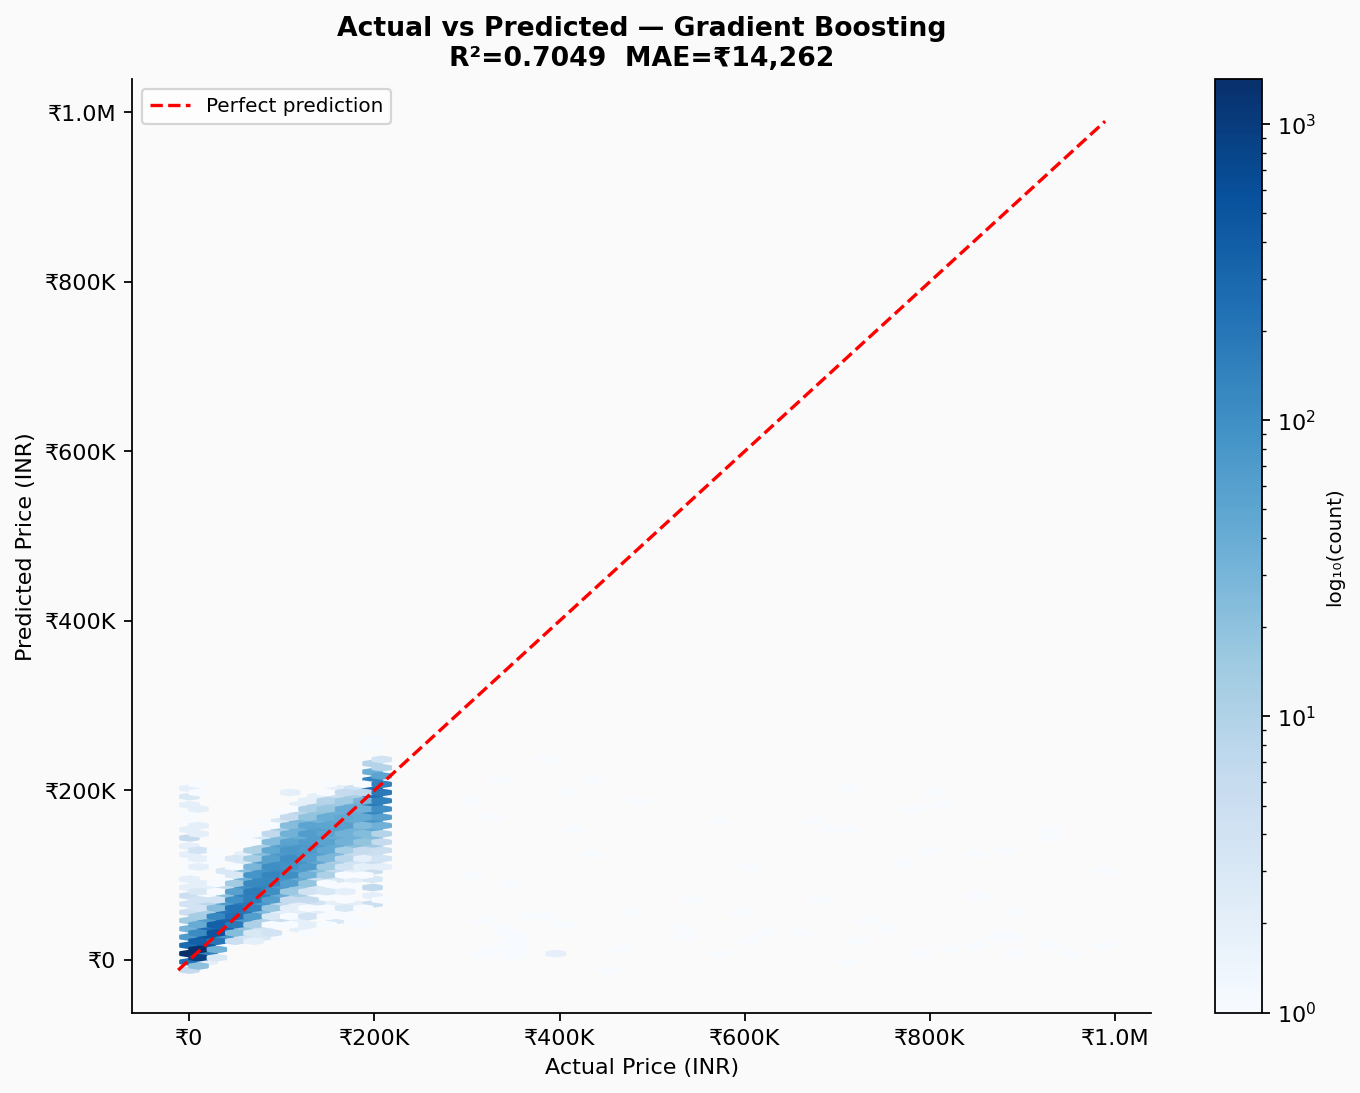

Displaying: feature_importance.png


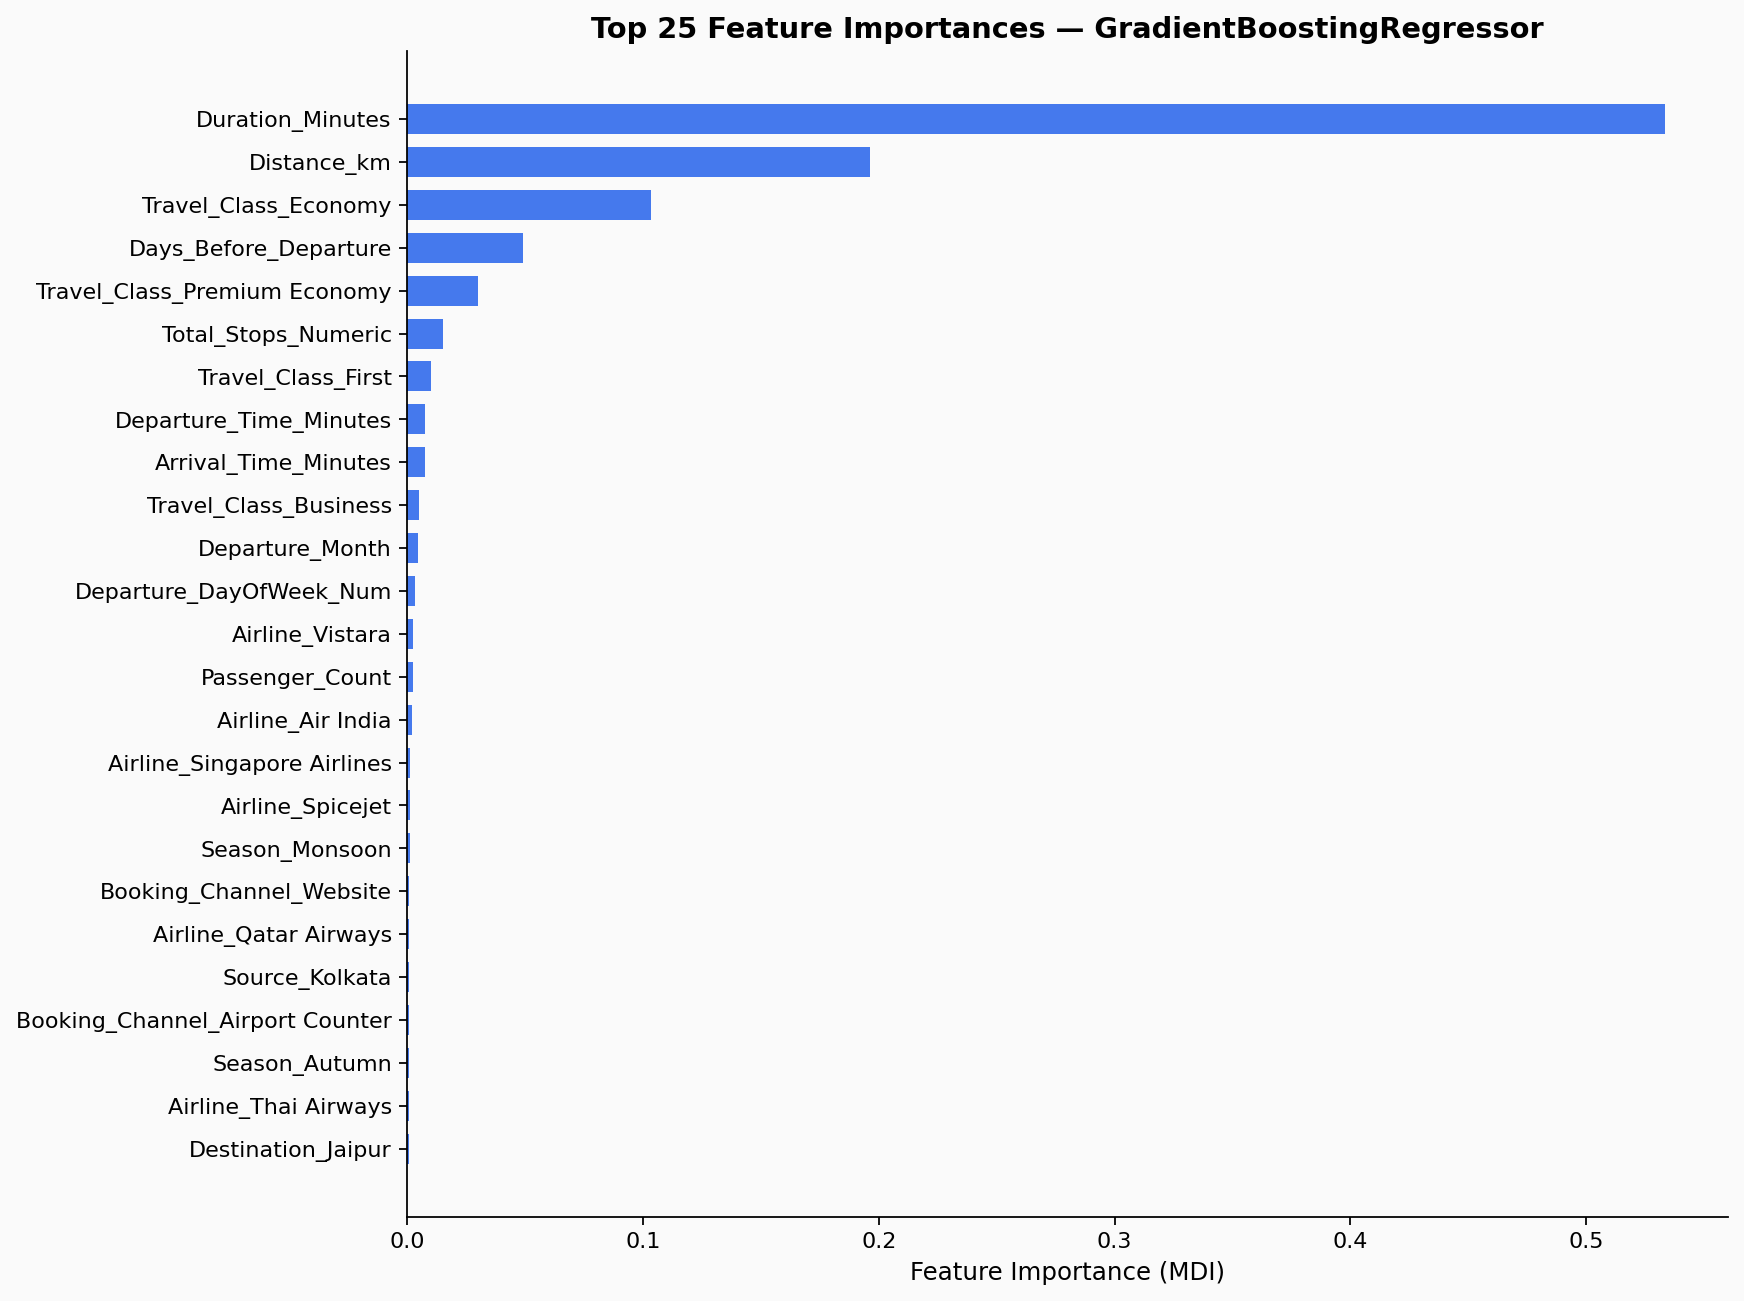

Displaying: model_comparison.png


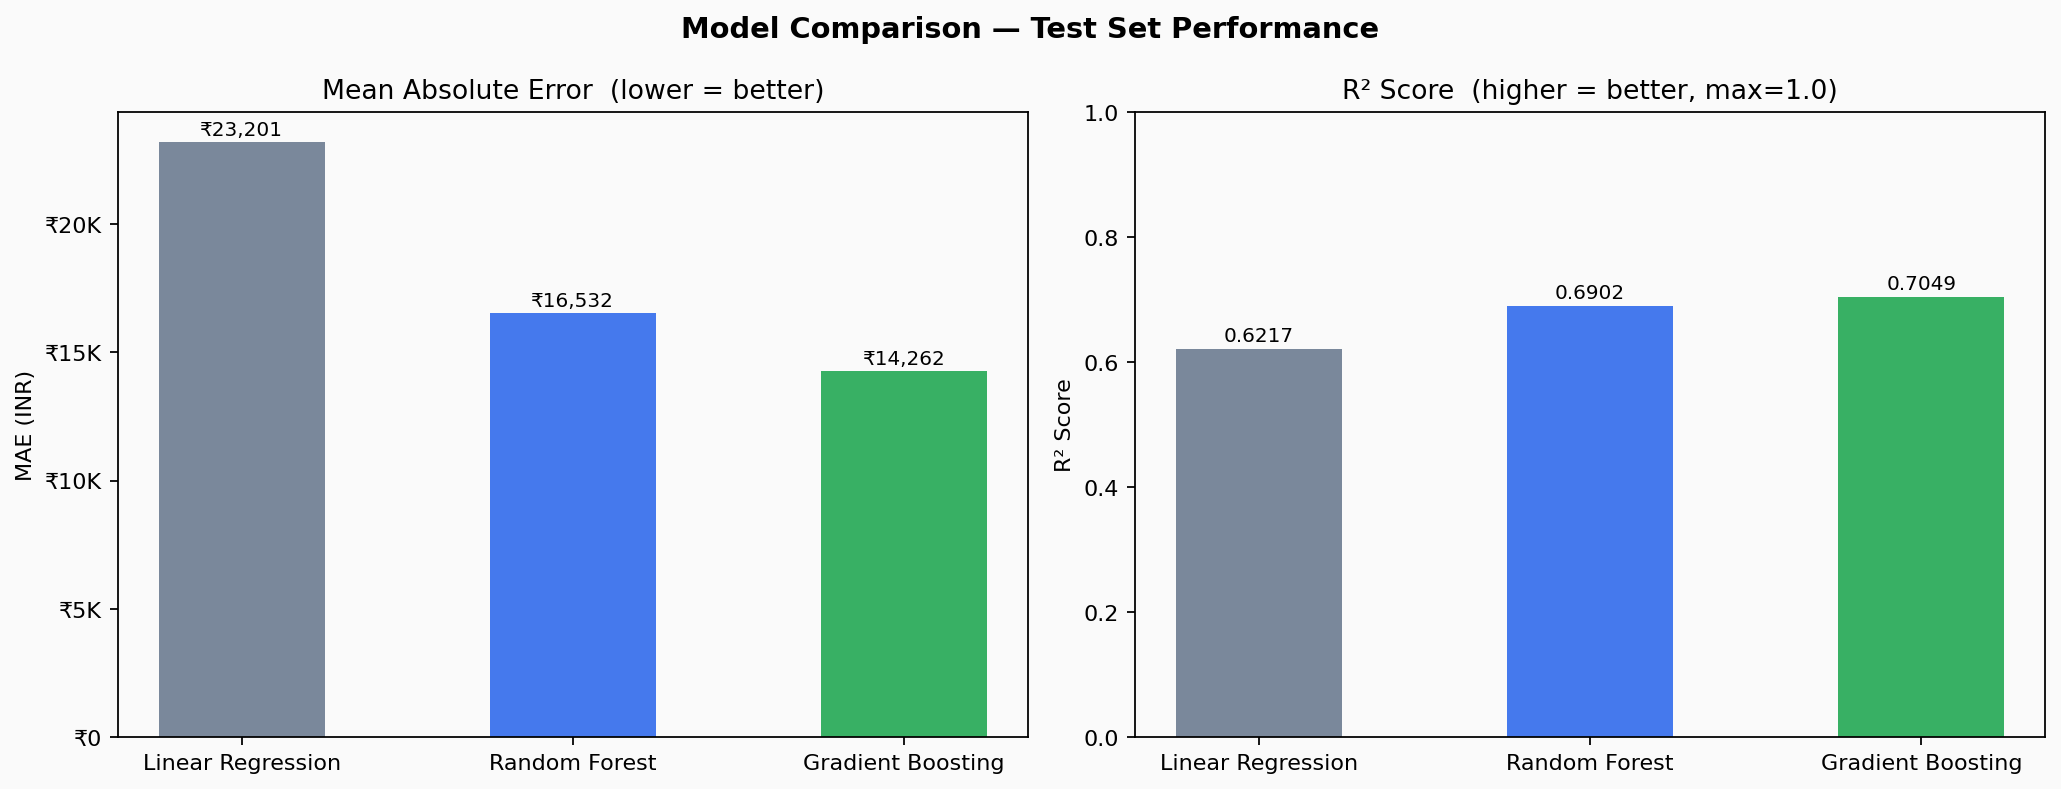

Displaying: residual_plot.png


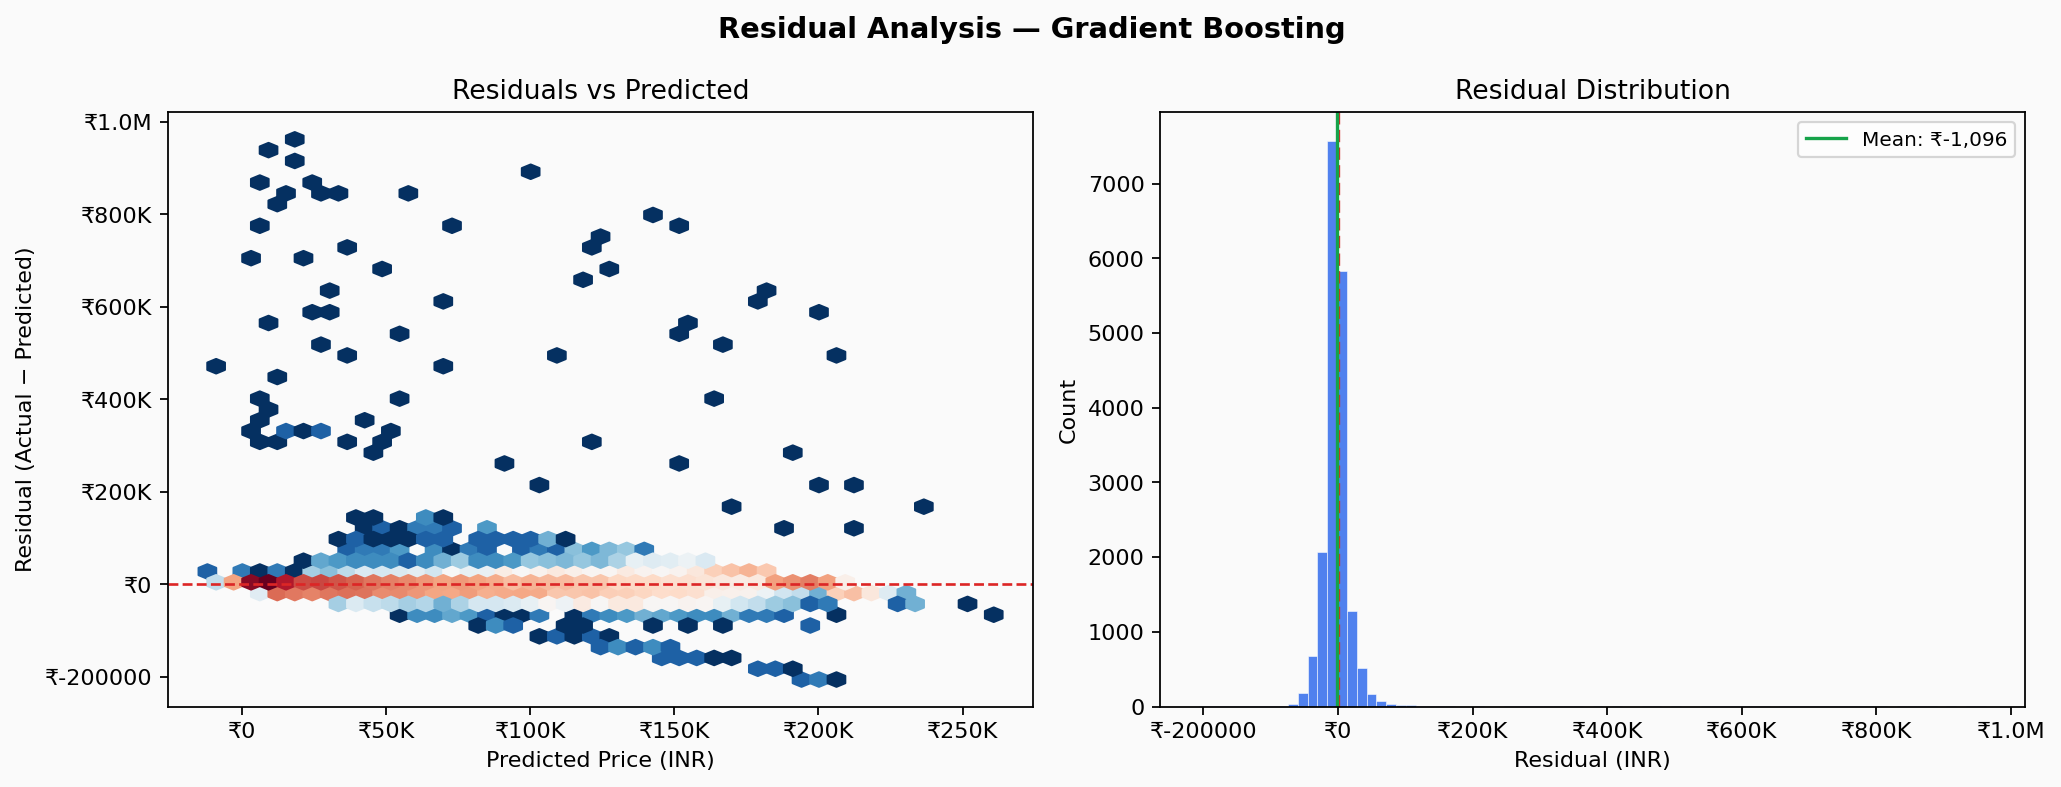

In [6]:
from IPython.display import Image, display
import glob
model_plots = sorted(glob.glob('../assets/model/*.png'))
for p in model_plots:
    print(f'Displaying: {os.path.basename(p)}')
    display(Image(filename=p))


## 6. Metadata

In [7]:
with open('../models/model_metadata.json') as f:
    meta = json.load(f)
print('Model metadata:')
print(f'  Best model      : {meta["best_model"]}')
print(f'  Train size      : {meta["train_size"]:,}')
print(f'  Test size       : {meta["test_size"]:,}')
print(f'  Raw features    : {meta["n_features_raw"]}')
print(f'  Encoded features: {meta["n_features_encoded"]}')
print(f'\n  Best metrics:')
bm = meta['best_metrics']
print(f'    MAE  : ₹{bm["MAE"]:>10,.0f}')
print(f'    RMSE : ₹{bm["RMSE"]:>10,.0f}')
print(f'    R²   : {bm["R2"]:.4f}')


Model metadata:
  Best model      : Gradient Boosting
  Train size      : 74,466
  Test size       : 18,617
  Raw features    : 17
  Encoded features: 86

  Best metrics:
    MAE  : ₹    14,262
    RMSE : ₹    40,262
    R²   : 0.7049
